___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Авторские права принадлежат Pierian Data Inc.</em></center>
<center><em>Для дополнительной информации посетите наш сайт <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Упражнения по логистической регрессии

**Задача: Создать модель классификации для предосказания того, есть ли у пациента признаки болезни сердца, в зависимости от физических характеристик этого человека (возраст, пол, холистерол и т.д.)**

**Выполните задания, указанные жирным шрифтом.**

## Imports

**ЗАДАНИЕ: Выполните команду ниже, чтобы импортировать нужные библиотеки.**

In [228]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Данные

В базе данных содержатся 14 атрибутов о физическом тестировании пациентов. Они сдают кровь и выполняют небольшой физический тест. Колонка "goal" указывает на наличие заболевания сердца у пациента - 0 означает заболевания нет, 1 означает заболевание есть. В общем случае, подтвердить на 100% заболевание сердца это очень инвазивный процесс, поэтому если мы сможем построить модель, которая достаточно точно оценивает вероятность заболевания, то это поможет избежать дорогих инвазивных процедур.

Содержимое

Информация об атрибутах:

* age - возраст
* sex - пол
* cp - chest pain - тип боли в груди (4 значения)
* trestbps - resting blood pressure - давление в состоянии покоя
* chol - уровень холистерина в крови, в mg/dl
* fbs - fasting blood sugar - уровень сахара в крови, > 120 mg/dl
* restecg - resting electrocardiographic results - результаты электрокардиограммы (значнеия 0,1,2)
* thalach - максимальный пульс
* exang - exercise induced angina - возникновение ангины в результате упражнений
* oldpeak = пиковые значения в электрокардиограмме, как результат упражнений (по сравнению с состоянием покоя)
* slope - наклон пикового значения в электрокардиограмме, как результат упражнений (по сравнению с состоянием покоя)
* ca - количество крупных сосудов (0-3), окрашенных флурозопией
* thal -  3 = нормально; 6 = фиксированный дефект; 7 = обратимый дефект
* target - 0 означает отсутствие заболевания сердца, 1 означает наличие заболевания сердца

Источник: https://archive.ics.uci.edu/ml/datasets/Heart+Disease

----

**ЗАДАЧА: Запустите ячейку ниже, чтобы прочитать файл с данными.**

In [229]:
df = pd.read_csv('../DATA/heart.csv')

In [230]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [231]:
df['target'].unique()

array([1, 0], dtype=int64)

### Анализ данных и визуализация данных

Можете дополнительно исследовать данные.

**ЗАДАНИЕ: Посмотрите, есть ли в наборе данных отсутствующие значения, и создайте статистический отчёт о числовых колонках, как показано ниже.**

In [232]:
# Напишите Ваш код здесь
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [233]:
# Напишите Ваш код здесь
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### Задачи по визуализации данных

**ЗАДАНИЕ: Нарисуйте график bar plot, показывающий количество точек для каждого значения target.**

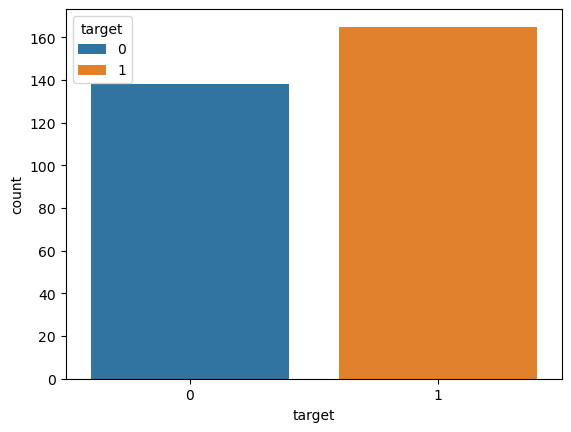

In [234]:
# Напишите Ваш код здесь
sns.countplot(data=df, x='target', hue='target')
plt.show();

**ЗАДАНИЕ: Нарисуйте график pairplot, показывающий связи между следующими колонками:**

    ['age','trestbps', 'chol','thalach','target']
   
*Замечание: если запустить pairplot по всем колонкам, то это заняло бы очень много времени, поскольку колонок много.*

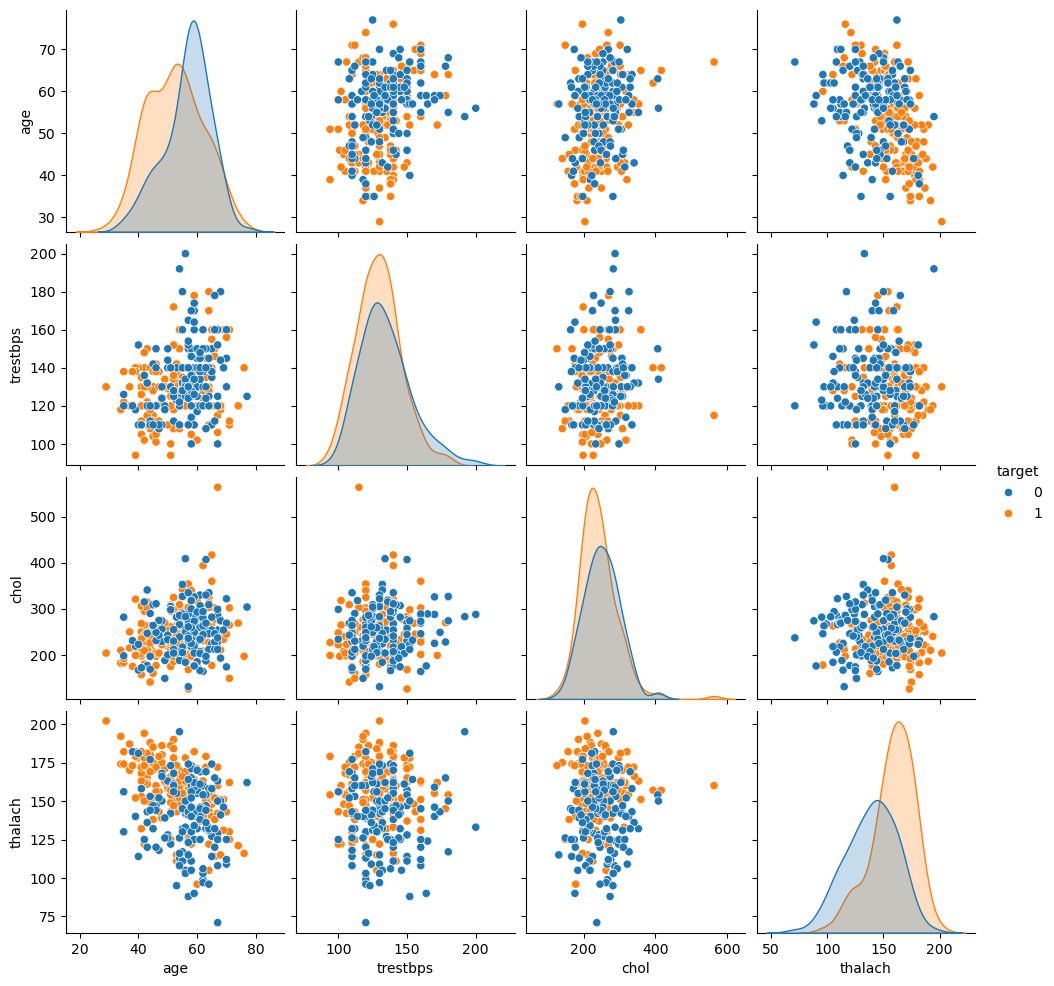

In [235]:
# Напишите Ваш код здесь
sns.pairplot(data=df[['age','trestbps', 'chol','thalach','target']], hue='target')
plt.show();

In [236]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

**ЗАДАНИЕ: Нарисуйте график heatmap, показывающий корреляции между всеми колонками.**

In [237]:
# Напишите Ваш код здесь
df_corr = df.corr()

<Axes: >

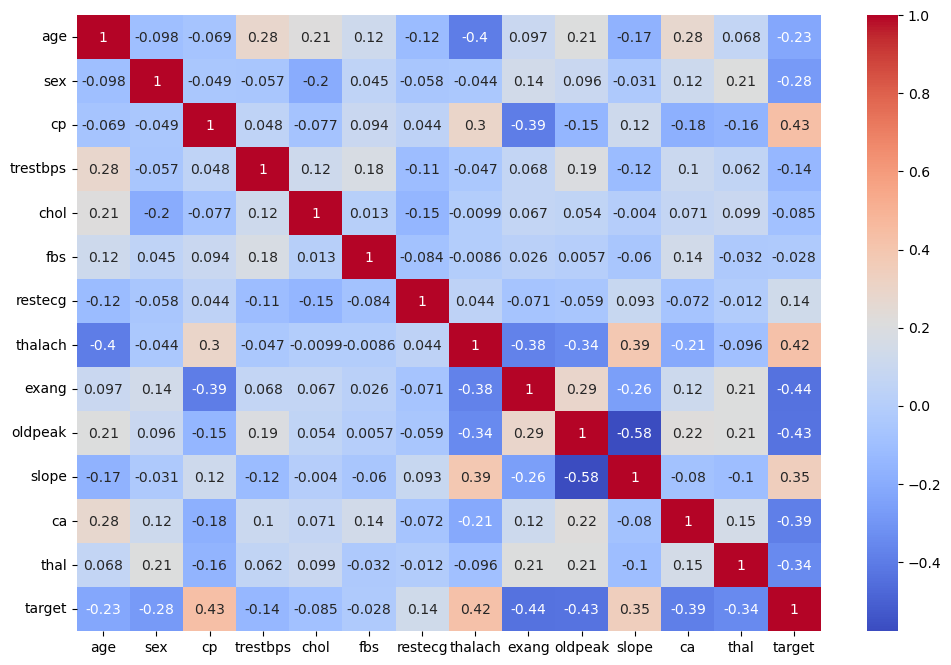

In [238]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr, cmap='coolwarm', annot=True)

C:\Users\pong\AppData\Local\Temp\ipykernel_5176\209061081.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df_corr['target'].abs().sort_values()[:-1], palette='YlGnBu')


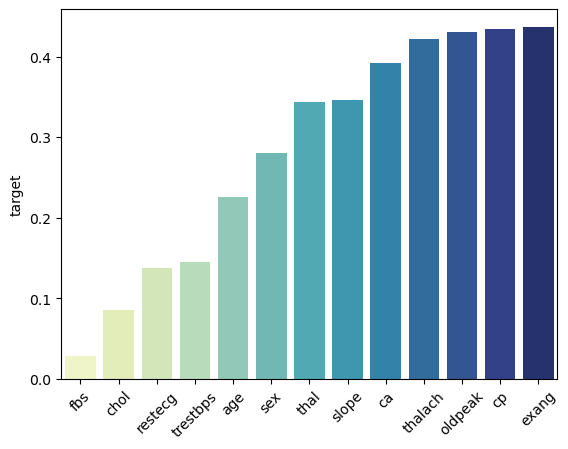

In [239]:
sns.barplot(df_corr['target'].abs().sort_values()[:-1], palette='YlGnBu')
plt.xticks(rotation=45)
plt.show();

----
----

# Машинное обучение

## Разбиение на обучающий и тестовый наборы данных, а также масштабирование данных

**ЗАДАНИЕ: разделите все признаки на 2 объекта, X и y.**

In [240]:
# Напишите Ваш код здесь
X = df.drop('target',axis=1)
y = df['target']

**ЗАДАНИЕ: разбейте данные на обучающий и тестовый наборы данных. Для тестовых данных используйте размер 10% и значение random_state=101.**

In [241]:
# Напишите Ваш код здесь
from sklearn.model_selection import train_test_split

In [242]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

**ЗАДАНИЕ: С помощью объекта StandardScaler нормализуйте данные признаков в обучающем и тестовом наборах данных. При дальнейшем обучении модели убедитесь, что Вы проводите обучение только на обучающем наборе данных (без утечки данных из тестового набора данных).**

In [243]:
# Напишите Ваш код здесь
from sklearn.preprocessing import StandardScaler

In [244]:
scaler = StandardScaler()

In [245]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

## Модель логистической регрессии

**ЗАДАНИЕ: Создайте модель логистической регрессии, и с помощью кросс-валидации найдите хорошее значение значение C. У Вас здесь есть 2 варианта - либо *LogisticRegressionCV*, либо комбинация *LogisticRegression* и *GridSearchCV*. Выбор за Вами. В блокноте с решениями мы используем более простой способ с использованием *LogisticRegressionCV*.**

In [266]:
# Напишите Ваш код здесь
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [267]:
base_log_model = LogisticRegression(solver='saga', max_iter=1000000)

In [268]:
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'l1_ratio': np.linspace(0, 1, 50),
    'C': [0.1, 1, 10, 100, 1000],
    }

In [269]:
gs_model = GridSearchCV(estimator=base_log_model, 
                        param_grid=param_grid,
                        scoring='accuracy',
                        cv=5,
                        n_jobs=-1,
                        verbose=3)

In [270]:
gs_model.fit(scaled_X_train, y_train)

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits


c:\Users\pong\anaconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=1000000, solver='saga'),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'l1_ratio': array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
       0.10204082, 0.12244898, 0.14285714, 0.16326531, 0.18367347,
       0.20408163, 0.2244898 , 0.24489796, 0.26530612, 0.28571429,
       0.30612245, 0.32653061, 0.34693878, 0.36734694, 0.38775...
       0.40816327, 0.42857143, 0.44897959, 0.46938776, 0.48979592,
       0.51020408, 0.53061224, 0.55102041, 0.57142857, 0.59183673,
       0.6122449 , 0.63265306, 0.65306122, 0.67346939, 0.69387755,
       0.71428571, 0.73469388, 0.75510204, 0.7755102 , 0.79591837,
       0.81632653, 0.83673469, 0.85714286, 0.87755102, 0.89795918,
       0.91836735, 0.93877551, 0.95918367, 0.97959184, 1.        ]),
                         'penalty': ['l1', 'l2', 'elasticnet', None]},
             scoring='accuracy', verbose=3)

**ЗАДАНИЕ: Отобразите результаты поиска оптимальных параметров, особенно значение C.** 

*Замечание: Ваше значение может отличаться от найденного нами, поскольку оно зависит от метода поиска.*

In [271]:
# Напишите Ваш код здесь
gs_model.best_estimator_.get_params()

{'C': 1,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 1000000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l1',
 'random_state': None,
 'solver': 'saga',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

### Коэффициенты

**ЗАДАНИЕ: Отобразите коэффициенты модели.**

In [272]:
gs_model.best_estimator_.coef_

array([[-0.04783604, -0.69655072,  0.88803523, -0.23905989, -0.18655501,
         0.00237807,  0.09601813,  0.42199591, -0.40862185, -0.52440942,
         0.3577827 , -0.83237105, -0.56448924]])

**БОНУСНОЕ ЗАДАНИЕ: Мы не показывали это в блокноте лекции, но у Вас есть все навыки, чтобы сделать это! Сделайте визуализацию коэффициентов, нарисуя их с помощью графика barplot. Дополнительно можете попробовать выяснить, как отсортировать график! Если что-то будет не получаться, то смело заглядывайте в блокнот с решениями - это можно сделать разными способами, в нашем решении мы используем комбинацию pandas и seaborn.**

In [273]:
# Напишите Ваш код здесь

In [274]:
coefs = pd.Series(index=X.columns,data=gs_model.best_estimator_.coef_[0])

In [275]:
coefs = coefs.sort_values()

C:\Users\pong\AppData\Local\Temp\ipykernel_5176\3258748495.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs.index, y=coefs.values, palette='pastel')


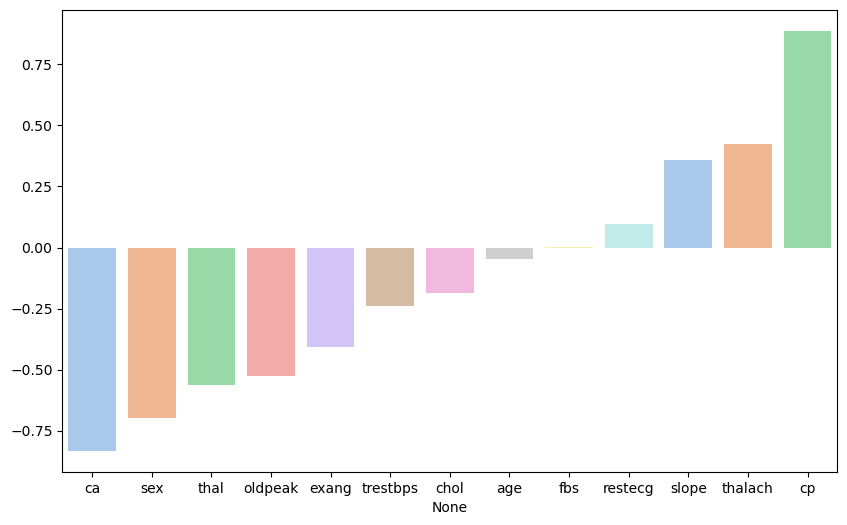

In [276]:
plt.figure(figsize=(10,6))
sns.barplot(x=coefs.index, y=coefs.values, palette='pastel')
plt.show();

---------

## Оценка модели

**ЗАДАНИЕ: Оцените работу модели на оставшихся 10% данных - тестовом наборе данных.**

**ЗАДАНИЕ: Подготовьте следующие оценки:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [277]:
# Напишите Ваш код здесь
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [278]:
y_pred = gs_model.predict(scaled_X_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[12,  3],
       [ 2, 14]], dtype=int64)

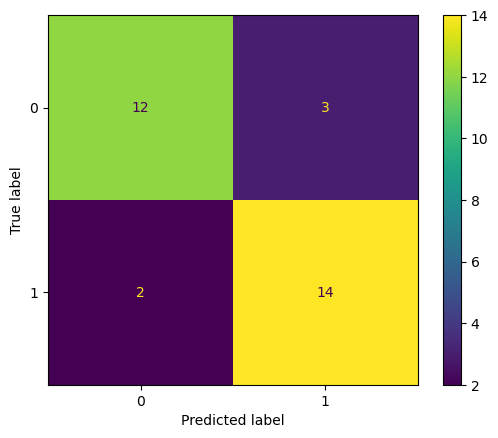

In [280]:
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=gs_model.classes_)
disp_cm.plot()
plt.show();

In [281]:
# Напишите Ваш код здесь


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        15
           1       0.82      0.88      0.85        16

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



### Кривые производительности

**ЗАДАНИЕ: Нарисуйте графики "precision recall curve" и "ROC Curve".**

In [294]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

In [295]:
y_pred_proba = gs_model.predict_proba(scaled_X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
auc_score = auc(recall, precision)

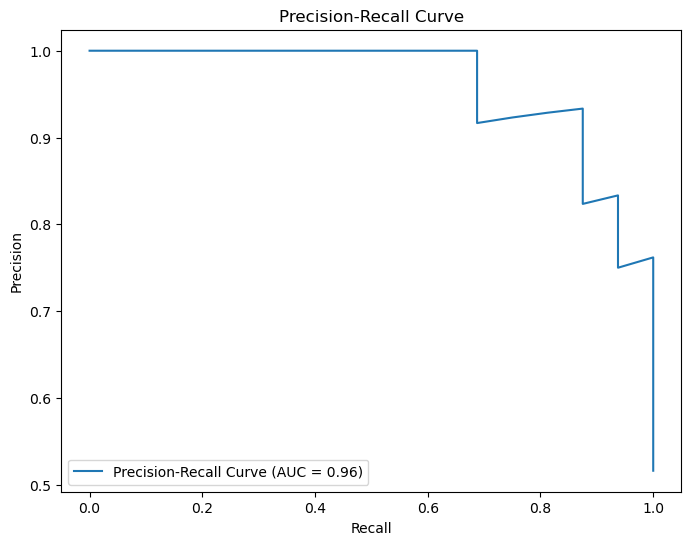

In [296]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {auc_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show();

In [297]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba) 
roc_auc = auc(fpr, tpr)

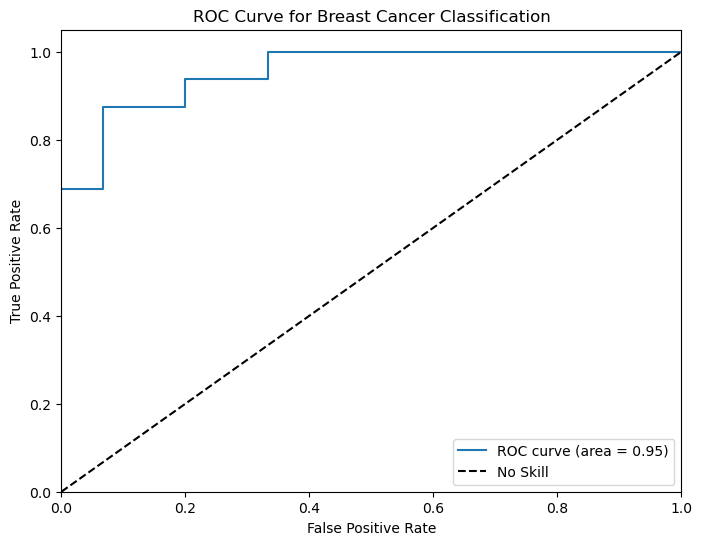

In [298]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Breast Cancer Classification')
plt.legend()
plt.show()

**Финальное задание: В офис клиники пришёл пациент со следующими значениями признаков:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**ЗАДАНИЕ: Что предскажет Ваша модель для этого пациента? Есть ли здесь заболевание сердца? Насколько модель "уверена" в своём прогнозе?**

*Для Вашего удобства мы создали массив с указанными выше значениями:*

In [265]:
patient = [[ 54. ,   1. ,   0. , 122. , 286. ,   0. ,   0. , 116. ,   1. ,
          3.2,   1. ,   2. ,   2. ]]

In [299]:
X_test.iloc[-1]

age          54.0
sex           1.0
cp            0.0
trestbps    122.0
chol        286.0
fbs           0.0
restecg       0.0
thalach     116.0
exang         1.0
oldpeak       3.2
slope         1.0
ca            2.0
thal          2.0
Name: 268, dtype: float64

In [310]:
y_test.iloc[-1]

0

In [311]:
scaled_patient = scaler.transform(patient)

c:\Users\pong\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [312]:
gs_model.predict(scaled_patient)

array([0], dtype=int64)

In [313]:
gs_model.predict_proba(scaled_patient)

array([[0.98921554, 0.01078446]])

In [356]:
for i in range(1, 10):
    patient = [scaled_X_test[i]]
    prediction = gs_model.predict(patient)
    prediction_proba = gs_model.predict_proba(patient)
    print(f'''Истинное значение:      {y_test.iloc[i]}
Предсказанное значение: {prediction[0]}
-------------------------------''')

Истинное значение:      1
Предсказанное значение: 1
-------------------------------
Истинное значение:      1
Предсказанное значение: 1
-------------------------------
Истинное значение:      1
Предсказанное значение: 1
-------------------------------
Истинное значение:      0
Предсказанное значение: 0
-------------------------------
Истинное значение:      1
Предсказанное значение: 1
-------------------------------
Истинное значение:      1
Предсказанное значение: 1
-------------------------------
Истинное значение:      0
Предсказанное значение: 0
-------------------------------
Истинное значение:      0
Предсказанное значение: 0
-------------------------------
Истинное значение:      1
Предсказанное значение: 1
-------------------------------


----

## Отличная работа!